In [1]:
import sys
import zipimport

# import zipped .py files
data_path = 'data_py_pkg.zip'
if data_path not in sys.path:
    sys.path.append(data_path)
    
from data_py_pkg import RACE_LUT, DISK_DISK_LUT
from data_py_pkg.sim_step import DISK_RADIUS, VALUE_SCALE, active_step, Perturbations

In [2]:
active_step

<function data_py_pkg.sim_step.active_step(sim, DISK_DISK_LUT)>

In [3]:
DISK_DISK_LUT.lut.shape

(21, 21, 41, 41, 4)

In [ ]:

# helper to convert nested list/dictionaries into list/objects-with-attributes
class obj:
    def __init__(self, d):
        for k, v in d.items():
            if isinstance(v, (list, tuple)):
                setattr(self, k, [obj(x) if isinstance(x, dict) else x for x in v])
            else:
                setattr(self, k, obj(v) if isinstance(v, dict) else v)
        
# build a new pseudo-random starting state for some disks ready to simulate
def buildSim(seed):
    Perturbations.setSeed(seed) 

    n_disks = 10
    x0 = DISK_RADIUS
    x1 = 100 * VALUE_SCALE - DISK_RADIUS

    # pick random x or y axis value to position disk
    random_coord = lambda: x0 + (Perturbations.nextInt() << 0) % (x1-x0)
    random_disk = lambda: {
        "currentState": {"x":random_coord(),"y":random_coord(),"dx":100,"dy":100},
        "nextState": {"x":1,"y":1,"dx":100,"dy":100}
    } 

    return obj({
        "disks": [
            random_disk() for i in range(n_disks)
        ],
        "winningDiskIndex": -1,
    })


seed = 1234
n_steps = 1000
sim = buildSim(seed)


print(f"initial: {sim.disks[0].currentState.x}")

for i in range(n_steps):
    active_step(sim,DISK_DISK_LUT)

print(f"state after {n_steps} steps: {sim.disks[0].currentState.x}")

initial state: 504831
state after 1000 steps: 619458


In [5]:
sim.disks[0].nextState.dy

100

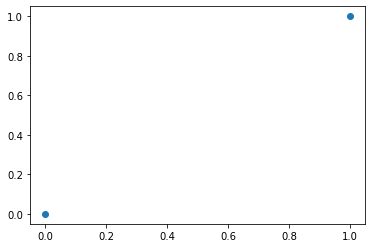

In [6]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter([0,1],[0,1])
plt.show()

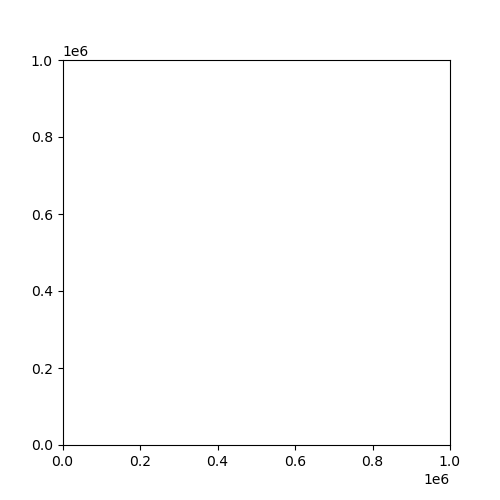

In [7]:
%matplotlib widget

import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot()


sc = ax.scatter([], [], s=DISK_RADIUS**.6, edgecolors='blue',color='red')
ax.set_xlim(0, 100 * VALUE_SCALE)
ax.set_ylim(0, 100 * VALUE_SCALE)

steps_per_frame = 10
def frames():
    for i in itertools.count():
        yield i

def animate(frame):
    for i in range(steps_per_frame):
        active_step(sim, DISK_DISK_LUT)
        
    sc.set_offsets([[d.currentState.x, d.currentState.y] for d in sim.disks])
    
    ax.set_title(f"{frame * steps_per_frame}")
    return sc,

ani = FuncAnimation(
    fig,
    animate,
    frames=frames(),         
    interval=20,
    repeat=False,
    cache_frame_data=False,  
    save_count=None,         
)

ani


In [8]:
len(sim.disks)

10

In [9]:
sim.disks[5].currentState.x


192371